Data Frame is loaded

=== Main Menu ===
1. Proportion of each card type for a specific education level (Task c1)
2. Monthly trend of average interest earned for each card category (Task c2)
3. Compare average annual fees and acquisition costs across card categories (Task c3)
4. Number of customers per expense type (Stacked by Card Category) (Task c4)
0. Quit


Select an option (0-4):  4


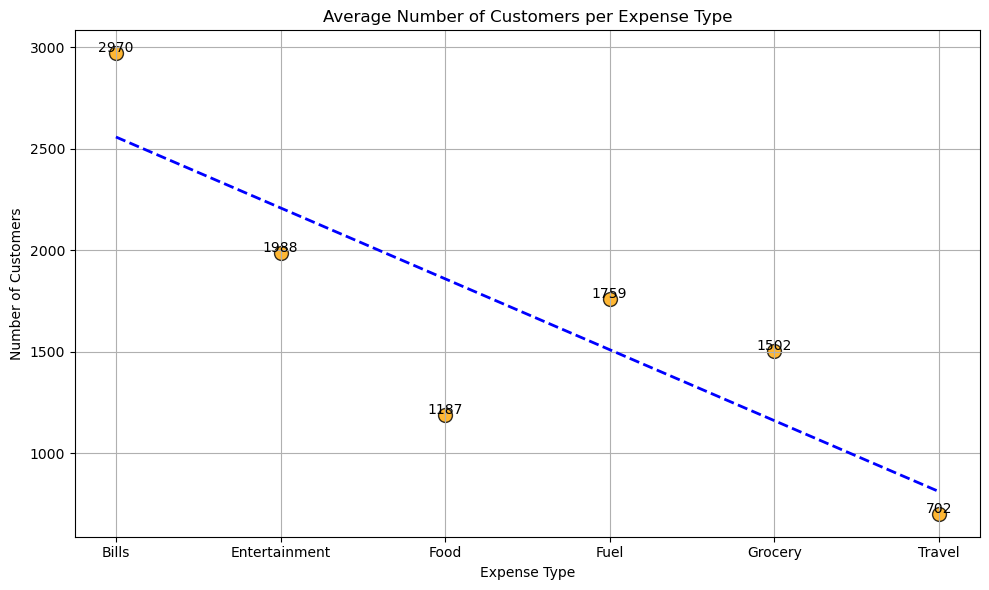


=== Main Menu ===
1. Proportion of each card type for a specific education level (Task c1)
2. Monthly trend of average interest earned for each card category (Task c2)
3. Compare average annual fees and acquisition costs across card categories (Task c3)
4. Number of customers per expense type (Stacked by Card Category) (Task c4)
0. Quit


In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the data from CSV file

def load_customer_data(file_path):
    # Read the CSV file into a DataFrame using UTF-8 encoding
    df = pd.read_csv(file_path, encoding='utf-8')
    print("Data Frame is loaded")
    return df

# ------------------------------
# Task c1: Proportion of each card type for a specific education level
# ------------------------------
def show_card_type_distribution(df):
    # Get unique education levels, removing any NaN values
    education_levels = df['Education_Level'].dropna().unique()
    
    while True:
        # Display menu to select education level
        print("\nSelect an Education Level (or type 0 to return to the main menu):")
        for idx, level in enumerate(education_levels):
            print(f"{idx + 1}. {level}")
        print("0. Return to Main Menu")

        try:
            # Get user input
            choice = int(input("Enter the number corresponding to your choice: "))
            if choice == 0:
                break
            elif 1 <= choice <= len(education_levels):
                # Filter data for the selected education level
                selected_level = education_levels[choice - 1]
                filtered_df = df[df['Education_Level'] == selected_level]

                if filtered_df.empty:
                    print(f"No data available for {selected_level}.")
                    continue

                # Count each card category
                card_counts = filtered_df['Card_Category'].value_counts()

                # Plot pie chart for card category proportions
                plt.figure()
                plt.pie(card_counts.values, labels=card_counts.index, autopct='%1.1f%%', startangle=90)
                plt.title(f'Proportion of Card Types for {selected_level}')
                plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
                plt.show()

                # Ask if user wants to view another level
                again = input("\nDo you want to try another education level? (Yes/No): ").strip().lower()
                if again != 'yes':
                    break
            else:
                print("Invalid number. Please select a valid option.")
        except ValueError:
            print("Invalid input. Please enter a number.")

# ------------------------------
# Task c2: Monthly trend of average interest earned for each card category
# ------------------------------
def plot_monthly_interest_trend(df):
    # Ensure 'Week_Num' column exists
    if 'Week_Num' not in df.columns:
        print("Week_Num column is missing!")
        return

    # Convert week numbers to integer and derive month number
    df['Week_Num'] = df['Week_Num'].str.replace('Week-', '').astype(int)
    df['Month'] = df['Week_Num'] // 4 + 1

    # Group by Month and Card_Category, compute mean Interest_Earned
    monthly_avg_interest = df.groupby(['Month', 'Card_Category'])['Interest_Earned'].mean().unstack()

    # Plot line chart of monthly average interest for each card category
    plt.figure(figsize=(10, 6))
    for card_cat in monthly_avg_interest.columns:
        plt.plot(monthly_avg_interest.index, monthly_avg_interest[card_cat], marker='o', label=card_cat)

    plt.title('Monthly Trend of Average Interest Earned by Card Category')
    plt.xlabel('Month')
    plt.ylabel('Average Interest Earned')
    plt.legend(title='Card Category')
    plt.grid(True)
    plt.xticks(range(1, 13))  # 12 months
    plt.tight_layout()
    plt.show()

# ------------------------------
# Task c3: Compare average annual fees and customer acquisition costs
# ------------------------------
def compare_avg_fees_and_acquisition_costs(df):
    # Calculate average annual fees by card category
    avg_fees = df.groupby('Card_Category')['Annual_Fees'].mean()
    
    # Calculate average acquisition cost by card category
    avg_acquisition = df.groupby('Card_Category')['Customer_Acq_Cost'].mean()

    # Prepare x-axis and bar positions
    card_categories = avg_fees.index
    x_axis = range(len(card_categories))
    bar_width = 0.4

    # Plot side-by-side bar chart
    plt.figure(figsize=(10, 6))
    plt.bar([x - 0.2 for x in x_axis], avg_fees.values, width=bar_width, label='Annual Fees', color='purple')
    plt.bar([x + 0.2 for x in x_axis], avg_acquisition.values, width=bar_width, label='Acquisition Cost', color='orange')

    plt.title('Average Annual Fees vs Acquisition Costs by Card Category')
    plt.xlabel('Card Category')
    plt.ylabel('Amount ($)')
    plt.xticks(x_axis, card_categories)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------
# Task c4: Number of customers per expense type (scatter + trend line)
# ------------------------------
def plot_avg_customers_per_expense_type(df):
    # Check if required column exists
    if 'Exp Type' not in df.columns:
        print("Required column 'Exp Type' is missing from the dataset.")
        return

    # Count number of customers by expense type
    exp_type_counts = df['Exp Type'].value_counts().sort_index()

    # Prepare data for scatter plot
    x = exp_type_counts.index.tolist()
    y = exp_type_counts.values.tolist()

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, s=100, color='orange', edgecolors='black', alpha=0.8)

    # Add text labels above each point
    for i, val in enumerate(y):
        plt.text(x[i], val + 5, str(val), ha='center')

    # Fit and plot linear trend line
    p = np.poly1d(np.polyfit(range(len(x)), y, 1))  # degree 1 = linear
    trend_x = range(len(x))
    trend_y = p(trend_x)
    plt.plot(trend_x, trend_y, color='blue', linestyle='--', linewidth=2)

    plt.title('Average Number of Customers per Expense Type')
    plt.xlabel('Expense Type')
    plt.ylabel('Number of Customers')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Main Menu Function 
# -----------------------------
def main_menu(df):
    while True:
        # Display main menu options
        print("\n=== Main Menu ===")
        print("1. Proportion of each card type for a specific education level (Task c1)")
        print("2. Monthly trend of average interest earned for each card category (Task c2)")
        print("3. Compare average annual fees and acquisition costs across card categories (Task c3)")
        print("4. Number of customers per expense type (Stacked by Card Category) (Task c4)")
        print("0. Quit")

        try:
            # Get user choice
            choice = int(input("Select an option (0-4): "))
            if choice == 0:
                print("\nThank you for using our customer data explorer. Goodbye!")
                break
            elif choice == 1:
                show_card_type_distribution(df)
            elif choice == 2:
                plot_monthly_interest_trend(df)
            elif choice == 3:
                compare_avg_fees_and_acquisition_costs(df)
            elif choice == 4:
                plot_avg_customers_per_expense_type(df)
            else:
                print("Invalid option. Please select a number between 0 and 4.")
        except ValueError:
            print("Invalid input. Please enter a number.")

# ------------------------------
# Main driver function
# ------------------------------
def visualizing_customer_information():
    # Define the path to the CSV file
    file_path = "credit_card_customers.csv"
    
    # Load the customer data
    df_ccard = load_customer_data(file_path)

    # Launch the interactive menu
    main_menu(df_ccard)

# -----------------------------
# Run the main function
# -----------------------------
if __name__ == "__main__":
    visualizing_customer_information()
